In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles, make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

np.random.seed(42)
print("Imports done!")

Imports done!


Training samples: (400, 2)
Test samples:     (100, 2)
Features:         2


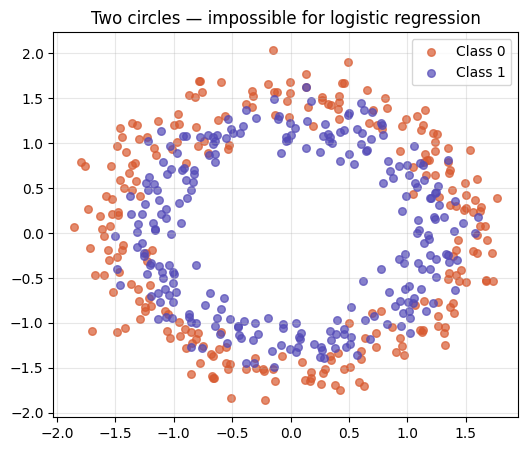

In [2]:
# make_circles creates two concentric rings
# Linear models CANNOT separate these — perfect for neural networks
X, y = make_circles(n_samples=500, noise=0.1, random_state=42)
y = y.reshape(-1, 1)  # reshape to column vector (500, 1)

# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {X_train.shape}")
print(f"Test samples:     {X_test.shape}")
print(f"Features:         {X_train.shape[1]}")

# Plot the data
plt.figure(figsize=(6, 5))
plt.scatter(X[y.flatten()==0, 0], X[y.flatten()==0, 1],
            c='#D85A30', label='Class 0', alpha=0.7, s=30)
plt.scatter(X[y.flatten()==1, 0], X[y.flatten()==1, 1],
            c='#534AB7', label='Class 1', alpha=0.7, s=30)
plt.title('Two circles — impossible for logistic regression')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [3]:
# Every activation function and its gradient

def sigmoid(z):
    """Squash to 0-1. Used in OUTPUT layer for binary classification."""
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def sigmoid_grad(z):
    """Gradient of sigmoid. Used in backpropagation."""
    s = sigmoid(z)
    return s * (1 - s)

def relu(z):
    """Pass positive values, zero out negatives. Used in HIDDEN layers."""
    return np.maximum(0, z)

def relu_grad(z):
    """Gradient of ReLU. 1 where z>0, 0 elsewhere."""
    return (z > 0).astype(float)

# Test them
z_test = np.array([-2, -1, 0, 1, 2])
print("Input z:        ", z_test)
print("sigmoid(z):     ", sigmoid(z_test).round(3))
print("sigmoid_grad(z):", sigmoid_grad(z_test).round(3))
print("relu(z):        ", relu(z_test))
print("relu_grad(z):   ", relu_grad(z_test))

Input z:         [-2 -1  0  1  2]
sigmoid(z):      [0.119 0.269 0.5   0.731 0.881]
sigmoid_grad(z): [0.105 0.197 0.25  0.197 0.105]
relu(z):         [0 0 0 1 2]
relu_grad(z):    [0. 0. 0. 1. 1.]


In [4]:
def initialise_weights(n_input, n_hidden, n_output):
    """
    He initialisation for ReLU layers.
    Scale by sqrt(2/n_input) to keep variance stable across layers.
    Too large → exploding gradients.
    Too small → vanishing gradients.
    He initialisation is the sweet spot for ReLU networks.
    """
    np.random.seed(42)

    W1 = np.random.randn(n_hidden, n_input) * np.sqrt(2 / n_input)
    b1 = np.zeros((n_hidden, 1))

    W2 = np.random.randn(n_output, n_hidden) * np.sqrt(2 / n_hidden)
    b2 = np.zeros((n_output, 1))

    params = {'W1': W1, 'b1': b1, 'W2': W2, 'b2': b2}

    print(f"W1 shape: {W1.shape}  ← {n_hidden} neurons, each with {n_input} weights")
    print(f"b1 shape: {b1.shape}  ← one bias per hidden neuron")
    print(f"W2 shape: {W2.shape}  ← {n_output} output neuron, each with {n_hidden} weights")
    print(f"b2 shape: {b2.shape}  ← one bias for output")
    print(f"\nTotal parameters: {W1.size + b1.size + W2.size + b2.size}")

    return params

params = initialise_weights(n_input=2, n_hidden=8, n_output=1)

W1 shape: (8, 2)  ← 8 neurons, each with 2 weights
b1 shape: (8, 1)  ← one bias per hidden neuron
W2 shape: (1, 8)  ← 1 output neuron, each with 8 weights
b2 shape: (1, 1)  ← one bias for output

Total parameters: 33


In [5]:
def forward_pass(X, params):
    """
    Data flows LEFT TO RIGHT through the network.

    Layer 1 (hidden):
      Z1 = W1 @ X.T + b1   ← weighted sum for all hidden neurons
      A1 = ReLU(Z1)         ← apply activation

    Layer 2 (output):
      Z2 = W2 @ A1 + b2    ← weighted sum for output neuron
      A2 = sigmoid(Z2)      ← squeeze to probability

    Returns predictions AND cache (needed for backprop).
    """
    W1, b1 = params['W1'], params['b1']
    W2, b2 = params['W2'], params['b2']

    # Layer 1: input → hidden
    Z1 = W1 @ X.T + b1        # shape: (n_hidden, n_samples)
    A1 = relu(Z1)              # shape: (n_hidden, n_samples)

    # Layer 2: hidden → output
    Z2 = W2 @ A1 + b2          # shape: (1, n_samples)
    A2 = sigmoid(Z2)           # shape: (1, n_samples)

    # Cache everything needed for backprop
    cache = {'Z1': Z1, 'A1': A1, 'Z2': Z2, 'A2': A2, 'X': X}

    return A2, cache

# Test forward pass
A2_test, cache_test = forward_pass(X_train[:3], params)
print("Forward pass test (3 samples):")
print(f"Predictions: {A2_test.flatten().round(4)}")
print(f"(Random weights → predictions near 0.5 expected)")

Forward pass test (3 samples):
Predictions: [0.1533 0.2959 0.2223]
(Random weights → predictions near 0.5 expected)


In [7]:
def compute_cost(A2, y):
    """
    Binary cross-entropy loss.
    Loss = -(y*log(ŷ) + (1-y)*log(1-ŷ))

    A2 shape: (1, n_samples) ← network output
    y  shape: (n_samples, 1) ← true labels

    We need to align shapes before multiplying.
    """
    m = y.shape[0]
    epsilon = 1e-7  # prevent log(0)

    # A2 is (1, m) — squeeze to (m,) for element-wise ops
    A2_flat = A2.flatten()
    y_flat  = y.flatten()

    # Clip to avoid log(0)
    A2_clipped = np.clip(A2_flat, epsilon, 1 - epsilon)

    # Element-wise loss then average
    loss = -(y_flat * np.log(A2_clipped) +
             (1 - y_flat) * np.log(1 - A2_clipped))

    cost = float(np.mean(loss))
    return cost

# Test cost
cost_test = compute_cost(A2_test, y_train[:3])
print(f"Cost with random weights: {cost_test:.4f}")
print("(Should be near 0.69 = -log(0.5) for random predictions)")

Cost with random weights: 0.9626
(Should be near 0.69 = -log(0.5) for random predictions)


In [8]:
def backward_pass(params, cache, y):
    """
    Gradients flow RIGHT TO LEFT through the network.
    Uses chain rule to compute how much each weight
    contributed to the loss.

    Output layer gradient:
      dZ2 = A2 - y              ← error at output
      dW2 = dZ2 @ A1.T / m     ← how much W2 contributed
      db2 = mean(dZ2)

    Hidden layer gradient:
      dA1 = W2.T @ dZ2          ← error propagated back
      dZ1 = dA1 * ReLU_grad(Z1) ← apply ReLU gradient
      dW1 = dZ1 @ X / m
      db1 = mean(dZ1)
    """
    W2 = params['W2']
    Z1, A1, Z2, A2, X = (cache['Z1'], cache['A1'],
                          cache['Z2'], cache['A2'], cache['X'])
    m = X.shape[0]

    # ── OUTPUT LAYER ─────────────────────────────────────────────────
    dZ2 = A2 - y.T              # error at output (prediction - truth)
    dW2 = (dZ2 @ A1.T) / m     # gradient for W2
    db2 = np.mean(dZ2, axis=1, keepdims=True)  # gradient for b2

    # ── HIDDEN LAYER ──────────────────────────────────────────────────
    dA1 = W2.T @ dZ2            # propagate error backward through W2
    dZ1 = dA1 * relu_grad(Z1)  # apply ReLU gradient (chain rule)
    dW1 = (dZ1 @ X) / m        # gradient for W1
    db1 = np.mean(dZ1, axis=1, keepdims=True)  # gradient for b1

    grads = {'dW1': dW1, 'db1': db1, 'dW2': dW2, 'db2': db2}
    return grads

# Test backward pass
grads_test = backward_pass(params, cache_test, y_train[:3])
print("Gradient shapes (should match weight shapes):")
print(f"dW1: {grads_test['dW1'].shape} ← matches W1 {params['W1'].shape}")
print(f"db1: {grads_test['db1'].shape} ← matches b1 {params['b1'].shape}")
print(f"dW2: {grads_test['dW2'].shape} ← matches W2 {params['W2'].shape}")
print(f"db2: {grads_test['db2'].shape} ← matches b2 {params['b2'].shape}")

Gradient shapes (should match weight shapes):
dW1: (8, 2) ← matches W1 (8, 2)
db1: (8, 1) ← matches b1 (8, 1)
dW2: (1, 8) ← matches W2 (1, 8)
db2: (1, 1) ← matches b2 (1, 1)


In [9]:
def update_weights(params, grads, learning_rate):
    """
    Gradient descent update rule:
    weight = weight - learning_rate × gradient

    Negative gradient → weight increases
    Positive gradient → weight decreases
    Both move in the direction that reduces loss.
    """
    params['W1'] -= learning_rate * grads['dW1']
    params['b1'] -= learning_rate * grads['db1']
    params['W2'] -= learning_rate * grads['dW2']
    params['b2'] -= learning_rate * grads['db2']
    return params

print("Weight update function ready!")
print("""
The update rule in words:
  If gradient is negative → weight was too small → increase it
  If gradient is positive → weight was too large → decrease it
  Learning rate controls how big each step is
""")

Weight update function ready!

The update rule in words:
  If gradient is negative → weight was too small → increase it
  If gradient is positive → weight was too large → decrease it
  Learning rate controls how big each step is



In [10]:
def train(X_train, y_train, n_hidden=8, learning_rate=0.1,
          n_iterations=2000):
    """
    The complete training loop:
    1. Initialise random weights
    2. Forward pass → predictions
    3. Compute loss
    4. Backward pass → gradients
    5. Update weights
    6. Repeat
    """
    n_input  = X_train.shape[1]
    n_output = 1
    params   = initialise_weights(n_input, n_hidden, n_output)
    costs    = []

    for i in range(n_iterations):
        # Forward pass
        A2, cache = forward_pass(X_train, params)

        # Compute cost
        cost = compute_cost(A2, y_train)

        # Backward pass
        grads = backward_pass(params, cache, y_train)

        # Update weights
        params = update_weights(params, grads, learning_rate)

        # Record cost every 100 iterations
        if i % 100 == 0:
            costs.append(cost)
            if i % 500 == 0:
                print(f"Iteration {i:4d}: cost = {cost:.4f}")

    print(f"\nFinal cost: {cost:.4f}")
    return params, costs

# Train the network
print("Training neural network...")
params_trained, costs = train(
    X_train, y_train,
    n_hidden=8,
    learning_rate=0.1,
    n_iterations=2000
)

Training neural network...
W1 shape: (8, 2)  ← 8 neurons, each with 2 weights
b1 shape: (8, 1)  ← one bias per hidden neuron
W2 shape: (1, 8)  ← 1 output neuron, each with 8 weights
b2 shape: (1, 1)  ← one bias for output

Total parameters: 33
Iteration    0: cost = 0.7965
Iteration  500: cost = 0.5631
Iteration 1000: cost = 0.4669
Iteration 1500: cost = 0.4190

Final cost: 0.3981


Train accuracy: 82.75%
Test accuracy:  85.00%
Gap:            -2.25%


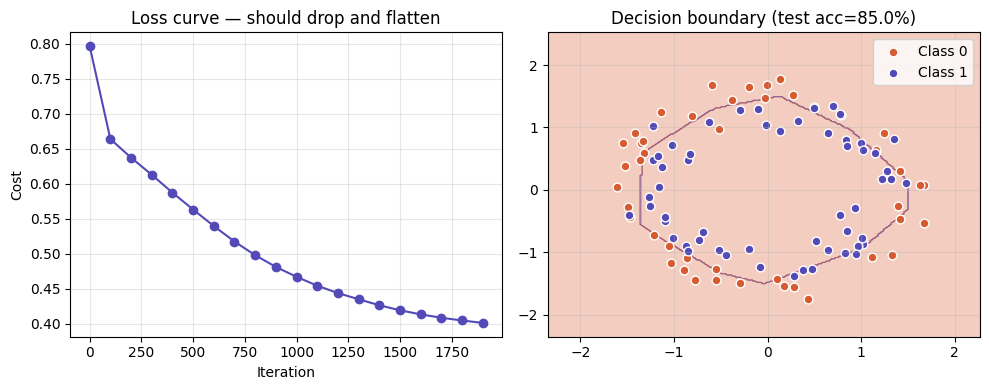

In [11]:
def predict(X, params):
    """Run forward pass and threshold at 0.5."""
    A2, _ = forward_pass(X, params)
    return (A2 > 0.5).astype(int).flatten()

# Evaluate on test set
train_preds = predict(X_train, params_trained)
test_preds  = predict(X_test,  params_trained)

train_acc = accuracy_score(y_train, train_preds)
test_acc  = accuracy_score(y_test,  test_preds)

print(f"Train accuracy: {train_acc*100:.2f}%")
print(f"Test accuracy:  {test_acc*100:.2f}%")
print(f"Gap:            {(train_acc-test_acc)*100:.2f}%")

# Plot loss curve
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(range(0, 2000, 100), costs, 'o-', color='#534AB7')
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Loss curve — should drop and flatten')
plt.grid(True, alpha=0.3)

# Plot decision boundary
plt.subplot(1, 2, 2)
h = 0.02
x_min, x_max = X[:, 0].min()-0.5, X[:, 0].max()+0.5
y_min, y_max = X[:, 1].min()-0.5, X[:, 1].max()+0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = predict(grid, params_trained).reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.3,
             colors=['#D85A30', '#534AB7'])
plt.scatter(X_test[y_test.flatten()==0, 0],
            X_test[y_test.flatten()==0, 1],
            c='#D85A30', label='Class 0', s=40, edgecolors='white')
plt.scatter(X_test[y_test.flatten()==1, 0],
            X_test[y_test.flatten()==1, 1],
            c='#534AB7', label='Class 1', s=40, edgecolors='white')
plt.title(f'Decision boundary (test acc={test_acc*100:.1f}%)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
from sklearn.linear_model import LogisticRegression

# Logistic regression on the same data
lr = LogisticRegression()
lr.fit(X_train, y_train.flatten())
lr_acc = accuracy_score(y_test, lr.predict(X_test))

print("=" * 45)
print(f"Logistic Regression:  {lr_acc*100:.2f}%")
print(f"Neural Network:       {test_acc*100:.2f}%")
print(f"NN improvement:       +{(test_acc-lr_acc)*100:.2f}%")
print("=" * 45)
print("""
Why NN wins:
  Logistic regression draws ONE straight line
  Two concentric circles cannot be separated by a line
  Neural network learns a CURVED boundary
  The hidden layer learns non-linear features of the input
  The output layer does logistic regression ON THOSE FEATURES
""")

Logistic Regression:  37.00%
Neural Network:       85.00%
NN improvement:       +48.00%

Why NN wins:
  Logistic regression draws ONE straight line
  Two concentric circles cannot be separated by a line
  Neural network learns a CURVED boundary
  The hidden layer learns non-linear features of the input
  The output layer does logistic regression ON THOSE FEATURES



In [13]:
results = {}

for n_hidden in [1, 2, 4, 8, 16]:
    p, _ = train(X_train, y_train,
                 n_hidden=n_hidden,
                 learning_rate=0.1,
                 n_iterations=1000)
    acc = accuracy_score(y_test, predict(X_test, p))
    results[n_hidden] = acc
    print(f"Hidden neurons={n_hidden:2d}: test accuracy={acc*100:.1f}%")

print("\nMore neurons = more capacity = better at complex patterns")
print("But too many → overfitting (train >> test)")

W1 shape: (1, 2)  ← 1 neurons, each with 2 weights
b1 shape: (1, 1)  ← one bias per hidden neuron
W2 shape: (1, 1)  ← 1 output neuron, each with 1 weights
b2 shape: (1, 1)  ← one bias for output

Total parameters: 5
Iteration    0: cost = 0.7243
Iteration  500: cost = 0.6925

Final cost: 0.6925
Hidden neurons= 1: test accuracy=43.0%
W1 shape: (2, 2)  ← 2 neurons, each with 2 weights
b1 shape: (2, 1)  ← one bias per hidden neuron
W2 shape: (1, 2)  ← 1 output neuron, each with 2 weights
b2 shape: (1, 1)  ← one bias for output

Total parameters: 9
Iteration    0: cost = 0.6853
Iteration  500: cost = 0.6717

Final cost: 0.6590
Hidden neurons= 2: test accuracy=50.0%
W1 shape: (4, 2)  ← 4 neurons, each with 2 weights
b1 shape: (4, 1)  ← one bias per hidden neuron
W2 shape: (1, 4)  ← 1 output neuron, each with 4 weights
b2 shape: (1, 1)  ← one bias for output

Total parameters: 17
Iteration    0: cost = 0.7039
Iteration  500: cost = 0.6467

Final cost: 0.5844
Hidden neurons= 4: test accuracy=